In [1]:
import numpy as np
import xarray as xr
import xarray.testing as xrt
from sdm_eurec4a import RepositoryPath

from pathlib import Path
import matplotlib.pyplot as plt

from sdm_eurec4a.visulization import label_from_attrs


In [2]:
clara = RepositoryPath(development_regime="levante_m300950")
nils = RepositoryPath(development_regime="levante_m301096") 

In [3]:
def get_clara_nils_dataset(relative_path : Path) -> [xr.Dataset, xr.Dataset] : 
    clara_ds = xr.open_dataset(clara.data_dir / relative_path)
    nils_ds = xr.open_dataset(nils.data_dir / relative_path)
    return dict(
        clara = clara_ds,
        nils = nils_ds
    )

def compare_clara_nils_dataset(relative_path : Path) -> None : 
    datasets = get_clara_nils_dataset(relative_path)
    print(f"Comparing datasets for {relative_path}")
    print("---------\nALL CLOSE\n---------")
    try: 
        xrt.assert_allclose(datasets["clara"], datasets["nils"], rtol=1e-20, atol=1e-10)
    except AssertionError as e: 
        print(f"Datasets are not equal for {relative_path}")
        print(e)
    print("---------\nIDENTICAL\n---------")
    try: 
        xrt.assert_identical(datasets["clara"], datasets["nils"])
    except AssertionError as e:
        print(f"Datasets are not identical for {relative_path}")
        print(e)
    print("---------\nEQUAL\n---------")
    try: 
            xrt.assert_equal(datasets["clara"], datasets["nils"])
    except AssertionError as e:
        print(f"Datasets are not equal for {relative_path}")
        print(e)
    

def plot_clara_nils_dataset(relative_path : Path) -> None :

    off_cloud_ids = [391, 393, 542, 164, 165, 166, 549, 569, 81, 83, 86, 88, 89, 92, 95, 486, 492, 239, 371, 250, 381, 127]
    datasets = get_clara_nils_dataset(relative_path=relative_path)
    x = datasets["clara"]
    y = datasets["nils"]

    abs_diff = y - x
    rel_diff = y / x

    data_vars = list(x.data_vars)

    # create a figure containing relative and absolute differences for each variable in the dataset
    # For this, each relative error shall be in the top row of the figures and the absolute error in the bottom row of the figures.
    # each variable shall have its own column in the figure. The figure shall have a title indicating the dataset being compared.
    fig, axs = plt.subplots(nrows=2, ncols=len(data_vars), figsize=(16/2, 9/2))
    fig.suptitle(f"Comparison of Clara and Nils datasets for {relative_path}")

    for col, var in enumerate(data_vars):
        
        axs[0, col].plot(rel_diff[var], '.')
        axs[1, col].plot(abs_diff[var], '.')
        axs[0, col].set_title(label_from_attrs(x[var], linebreak= True))

        # mark clouds which are off by more than 10% in the relative difference plot
        axs[0, col].plot(rel_diff[var].sel(cloud_id=off_cloud_ids), '.', color = 'red')
        axs[1, col].plot(abs_diff[var].sel(cloud_id=off_cloud_ids), '.', color = 'red')



    # add to left y-axis label to the top row of the figure "Relative difference"
    axs[0, 0].set_ylabel("Relative difference")
    # add to left y-axis label to the bottom row of the figure "Absolute difference"
    axs[1, 0].set_ylabel("Absolute difference")

    fig.tight_layout()

# Cloud composite dataset

In [4]:
relative_path = Path("observation/cloud_composite/processed/cloud_composite_SI_units_20241025.nc")
compare_clara_nils_dataset(relative_path=relative_path)

Comparing datasets for observation/cloud_composite/processed/cloud_composite_SI_units_20241025.nc
---------
ALL CLOSE
---------
---------
IDENTICAL
---------
Datasets are not identical for observation/cloud_composite/processed/cloud_composite_SI_units_20241025.nc
Left and right Dataset objects are not identical
Differing coordinates:
L * radius                                     (radius) float64 1kB 1.25e-06 ...
    Differing variable attributes:
        Long_name: drop diameter
R * radius                                     (radius) float64 1kB 1.25e-06 ...
Differing data variables:
L   particle_size_distribution                 (radius, time) float64 322MB 0...
    Differing variable attributes:
        Long_name: Particle Size Distribution
R   particle_size_distribution                 (radius, time) float64 322MB 0...
---------
EQUAL
---------


# Compare the identified clusters datasets

In [5]:
relative_path = Path("observation/cloud_composite/processed/identified_clusters/identified_clusters_rain_mask_5.nc")
compare_clara_nils_dataset(relative_path=relative_path)

Comparing datasets for observation/cloud_composite/processed/identified_clusters/identified_clusters_rain_mask_5.nc
---------
ALL CLOSE
---------
Datasets are not equal for observation/cloud_composite/processed/identified_clusters/identified_clusters_rain_mask_5.nc
Left and right Dataset objects are not close
Differing data variables:
L   duration                     (time) timedelta64[ns] 5kB 00:00:05 ... 00:0...
R   duration                     (time) int64 5kB 5 21 18 1 1 ... 1 1 32 1 208
---------
IDENTICAL
---------
Datasets are not identical for observation/cloud_composite/processed/identified_clusters/identified_clusters_rain_mask_5.nc
Left and right Dataset objects are not identical
Differing data variables:
L   mean_rain_water_content      (time) float64 5kB 0.01311 0.4351 ... 0.0 0.0
R   mean_rain_water_content      (time) float64 5kB 0.01311 0.4351 ... 0.0 0.0
L   duration                     (time) timedelta64[ns] 5kB 00:00:05 ... 00:0...
R   duration                     (t

In [6]:
datasets = get_clara_nils_dataset(relative_path=relative_path)
np.unique(datasets["clara"]["duration"].dt.total_seconds() - datasets["nils"]["duration"])

array([0.])

# Dropsonde dataset

In [7]:
relative_path = Path("observation/dropsonde/processed/drop_sondes.nc")
compare_clara_nils_dataset(relative_path=relative_path)

Comparing datasets for observation/dropsonde/processed/drop_sondes.nc
---------
ALL CLOSE
---------
---------
IDENTICAL
---------
---------
EQUAL
---------


# Distance relation

In [8]:
relative_path= Path("observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc")
compare_clara_nils_dataset(relative_path=relative_path)

Comparing datasets for observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc
---------
ALL CLOSE
---------
Datasets are not equal for observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc
Left and right Dataset objects are not close
Differing data variables:
L   temporal_distance          (time_identified_clouds, time_drop_sondes) timedelta64[ns] 5MB ...
R   temporal_distance          (time_identified_clouds, time_drop_sondes) int64 5MB ...
---------
IDENTICAL
---------
Datasets are not identical for observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc
Left and right Dataset objects are not identical
Differing coordinates:
L * time_identified_clouds     (time_identified_clouds) datetime64[ns] 5kB 20...
    Differing variable attributes:
        long_name: time of identified clouds measurments
        standard_name: time_cc
        axis: T
R * time_identified_clouds     (time_identified_clouds)

### The temporal distance is off by a factor of 1000 between both datasets, it is not clear what effect this has

In [9]:
datasets = get_clara_nils_dataset(relative_path=relative_path)
x = datasets["clara"]["temporal_distance"]
y = datasets["nils"]["temporal_distance"]
c_rel = y / (x.dt.total_seconds() * 1000)  # convert to seconds and then to milliseconds
c_abs = y - (x.dt.total_seconds() * 1000)  # convert to seconds and then to milliseconds
print(x.attrs)
print(y.attrs)

print(np.unique(c_rel))
print(np.unique(c_abs))

# fig, ax = plt.subplots()
# ax.pcolormesh(c, shading='auto')
# fig.colorbar(ax.collections[0], ax=ax, label="ratio of temporal distance")

{'long_name': 'temporal distance', 'comment': 'temporal distance between identified clouds (IC) and dropsonde launch time (DS). The values are IC - DS.'}
{'long_name': 'temporal distance', 'comment': 'temporal distance between identified clouds (IC) and dropsonde launch time (DS). The values are IC - DS.', 'units': 'milliseconds'}
[ 1. nan]
[0.]


# Input for CLEO

## Thermodynamics

## Relative Humidity

In [10]:
# relative_path=Path("model/input_v4.2/relative_humidity_parameters.nc")
compare_clara_nils_dataset(relative_path=relative_path)
plot_clara_nils_dataset(relative_path=relative_path)

Comparing datasets for observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc
---------
ALL CLOSE
---------
Datasets are not equal for observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc
Left and right Dataset objects are not close
Differing data variables:
L   temporal_distance          (time_identified_clouds, time_drop_sondes) timedelta64[ns] 5MB ...
R   temporal_distance          (time_identified_clouds, time_drop_sondes) int64 5MB ...
---------
IDENTICAL
---------
Datasets are not identical for observation/combined/distance/distance_dropsondes_identified_clusters_rain_mask_5.nc
Left and right Dataset objects are not identical
Differing coordinates:
L * time_identified_clouds     (time_identified_clouds) datetime64[ns] 5kB 20...
    Differing variable attributes:
        long_name: time of identified clouds measurments
        standard_name: time_cc
        axis: T
R * time_identified_clouds     (time_identified_clouds)

UFuncTypeError: ufunc 'divide' cannot use operands with types dtype('int64') and dtype('<m8[ns]')

## potential temperature

Comparing datasets for model/input_v4.2/potential_temperature_parameters.nc
---------
ALL CLOSE
---------
Datasets are not equal for model/input_v4.2/potential_temperature_parameters.nc
Left and right Dataset objects are not close
Differing data variables:
L   x_split   (cloud_id) float64 2kB 707.4 707.4 707.4 ... 824.7 811.2 789.8
R   x_split   (cloud_id) float64 2kB 707.4 707.4 707.4 ... 824.7 811.1 789.8
L   f_0       (cloud_id) float64 2kB 298.1 298.1 298.1 ... 298.2 298.2 298.0
R   f_0       (cloud_id) float64 2kB 298.1 298.1 298.1 ... 298.2 298.2 298.0
L   slope_2   (cloud_id) float64 2kB 0.004785 0.004785 ... 0.004364 0.004396
R   slope_2   (cloud_id) float64 2kB 0.004785 0.004785 ... 0.004364 0.004396
---------
IDENTICAL
---------
Datasets are not identical for model/input_v4.2/potential_temperature_parameters.nc
Left and right Dataset objects are not identical
Differing data variables:
L   x_split   (cloud_id) float64 2kB 707.4 707.4 707.4 ... 824.7 811.2 789.8
R   x_split   (

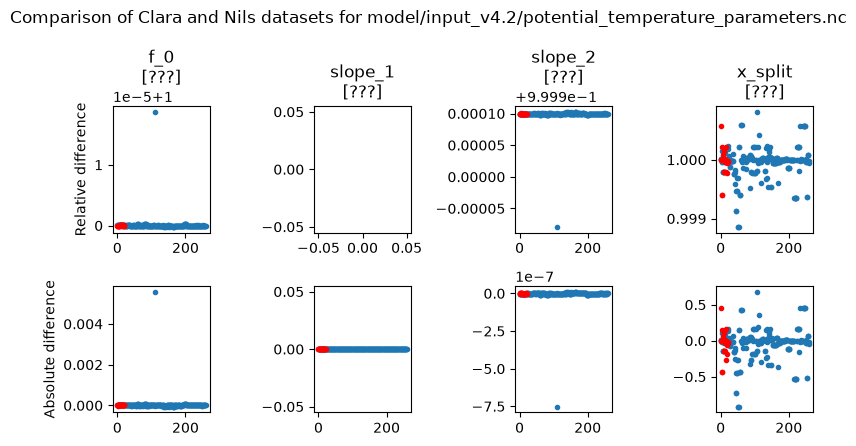

In [ ]:
relative_path=Path("model/input_v4.2/potential_temperature_parameters_linear_space.nc")
get_clara_nils_dataset(relative_path = relative_path)

## Particle Size Distribution

Comparing datasets for model/input_v4.2/particle_size_distribution_parameters_linear_space.nc
---------
ALL CLOSE
---------
Datasets are not equal for model/input_v4.2/particle_size_distribution_parameters_linear_space.nc
Left and right Dataset objects are not close
Differing data variables:
L   geometric_std_dev2  (cloud_id) float64 1kB 1.449 1.4 1.436 ... 1.5 1.595
R   geometric_std_dev2  (cloud_id) float64 1kB 1.59 1.4 1.4 ... 1.586 1.5 1.665
L   scale_factor1       (cloud_id) float64 1kB 1.012e+08 1.27e+07 ... 1.714e+06
R   scale_factor1       (cloud_id) float64 1kB 1.022e+08 1.27e+07 ... 2.649e+06
L   geometric_std_dev1  (cloud_id) float64 1kB 1.513 1.5 1.505 ... 1.6 1.604
R   geometric_std_dev1  (cloud_id) float64 1kB 1.5 1.5 1.5 ... 1.601 1.6 1.608
L   scale_factor2       (cloud_id) float64 1kB 338.3 1.844e+03 ... 0.6514 0.1297
R   scale_factor2       (cloud_id) float64 1kB 134.2 1.844e+03 ... 0.6514 0.2046
L   geometric_mean2     (cloud_id) float64 1kB 0.0003585 0.0003189 ... 0

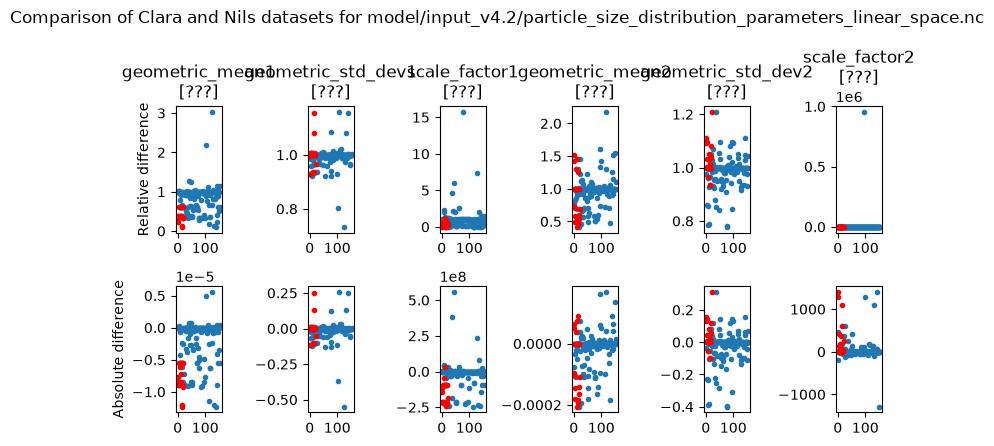

In [11]:
relative_path=Path("model/input_v4.2/particle_size_distribution_parameters_linear_space.nc")
compare_clara_nils_dataset(relative_path=relative_path)
plot_clara_nils_dataset(relative_path=relative_path)

# Look into DSDs

In [49]:

microphysics = [
    "coalbure_condensation_large",
    "coalbure_condensation_small",
    "collision_condensation",
    "condensation",
    "null_microphysics"
]

file_paths = [clara.CLEO_data_dir / "output_v4.2" / mp / "combined" / "conservation_dataset_combined.nc" for mp in microphysics]
datasets = [xr.open_dataset(fp) for fp in file_paths]

# use name of microphysics as coordinate
ds = xr.concat(datasets, dim=xr.DataArray(microphysics, dims="microphysics"), coords="all", join="outer")
# ds = ds.sel(time=TimeSlices.quasi_stationary_state)
ds = ds.isel(time=slice(0, -2))

ds["source"].attrs.update(long_name="Evaporation")

invalid_conservation_clouds = list({391, 393, 542, 164, 165, 166, 549, 569, 81, 83, 86, 88, 89, 92, 95, 486, 492, 239, 371, 250, 381, 127})
invalid_rwc_clouds = list({130, 387, 391, 393, 141, 398, 149, 415, 163, 164, 165, 166, 549,
       556, 569, 208,  83,  85,  86,  88,  89,  90,  92, 476,  95, 486,
       492, 239, 371, 250, 381, 127})
valid_clouds = list(set(ds["cloud_id"].values) - set(invalid_conservation_clouds))

In [56]:
print(set(invalid_conservation_clouds) - set(invalid_rwc_clouds))

{81, 542}


In [29]:
from pySD.initsuperdropsbinary_src import (
    attrsgen,
    crdgens,
    probdists,
    rgens,
)

In [30]:

from typing import Union, Tuple


def parameters_dataset_to_dict(
    ds: xr.Dataset, mapping: Union[dict[str, str], Tuple[str]]
) -> dict:
    """
    Convert selected parameters from an xarray Dataset to a dictionary with a given mapping.

    Parameters
    ----------
    ds : xr.Dataset
        The xarray Dataset containing the parameters.
    mapping : Union[dict[str, str], Tuple[str]]
        A mapping of parameter names to extract from the Dataset. If a dictionary is provided,
        the keys are the new names for the parameters and the values are the names in the Dataset.
        If a tuple or list is provided, the parameter names are used as-is.

    Returns
    -------
    dict
        A dictionary where the keys are the parameter names (or new names if a dictionary was provided)
        and the values are the corresponding values from the Dataset.

    Raises
    ------
    TypeError
        If the mapping is not a dictionary or a tuple/list.
    """

    if isinstance(mapping, (list, tuple)):
        parameters = {key: float(ds[key].values) for key in mapping}
    elif isinstance(mapping, dict):
        parameters = {mapping[key]: float(ds[key].values) for key in mapping}
    else:
        raise TypeError("mapping must be a dict or a tuple")

    return parameters


In [31]:
mapping = dict(
    geometric_mean1="geometric_mean1",
    geometric_mean2="geometric_mean2",
    geometric_std_dev1="geometric_std_dev1",
    geometric_std_dev2="geometric_std_dev2",
    scale_factor1="scale_factor1",
    scale_factor2="scale_factor2",
)

In [44]:
relative_path=Path("model/input_v4.2/particle_size_distribution_parameters_linear_space.nc")
d = get_clara_nils_dataset(relative_path = relative_path)
ds_psd = d["clara"]
cloud_user_dicts = {}
for user in ["clara", "nils"]:
    ds_user = d[user]
    cloud_dicts = {}
    for cloud_id in ds_user["cloud_id"].values:
        psd_params_dict = parameters_dataset_to_dict(ds_psd.sel(cloud_id=cloud_id), mapping=mapping)
        cloud_dicts[cloud_id] = psd_params_dict
    cloud_user_dicts[user] = cloud_dicts

In [47]:
distribution_user_dicts = {}
for user in ["clara", "nils"]:
    cloud_dicts = cloud_user_dicts[user]
    distribution_dict = {}
    for cloud_id in cloud_dicts:
        psd_params_dict = cloud_dicts[cloud_id]
        xi_probability_distribution = probdists.DoubleLogNormal(
            geometric_mean1=psd_params_dict["geometric_mean1"],
            geometric_mean2=psd_params_dict["geometric_mean2"],
        geometric_std_dev1=psd_params_dict["geometric_std_dev1"],
        geometric_std_dev2=psd_params_dict["geometric_std_dev2"],
        scale_factor1=psd_params_dict["scale_factor1"],
        scale_factor2=psd_params_dict["scale_factor2"],
        )
        distribution_dict[cloud_id] = xi_probability_distribution
    distribution_user_dicts[user] = distribution_dict


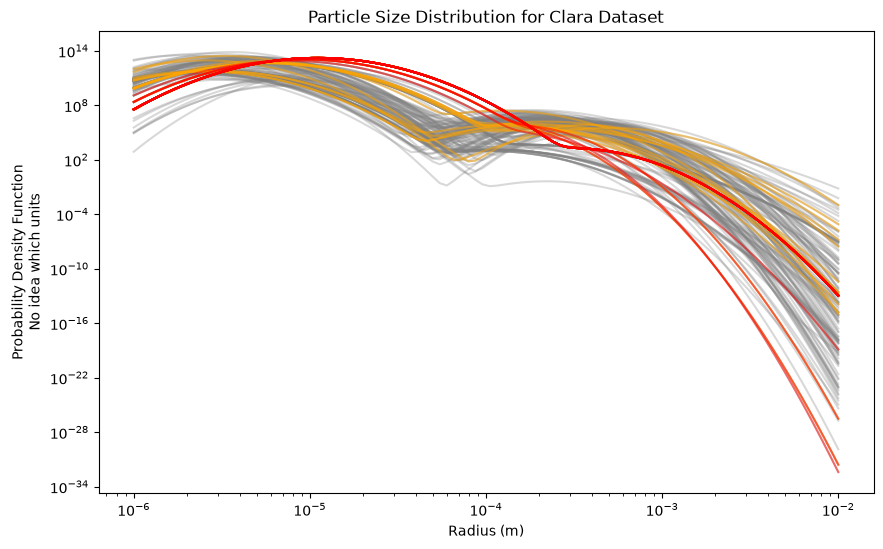

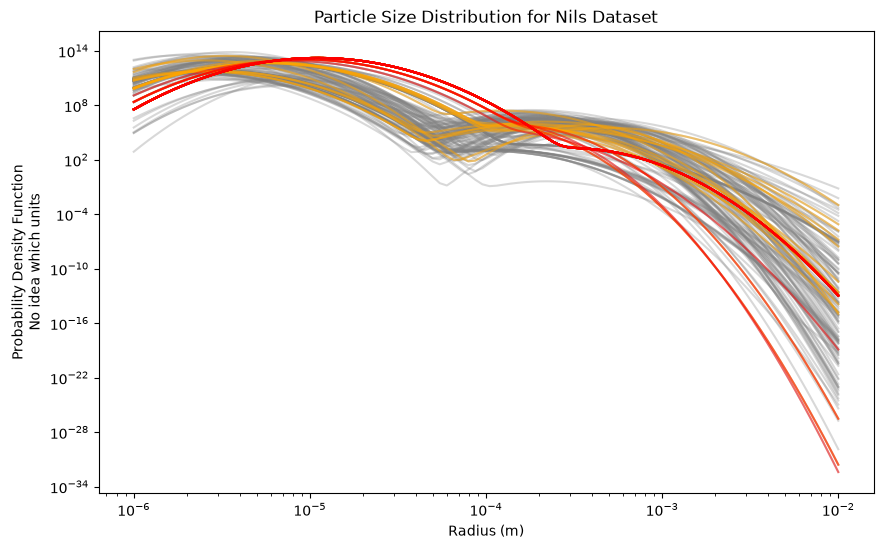

In [52]:
radii = np.logspace(-6, -2, 100)  # radii from 1e-6 to 1e-2 meters

for user in ["clara", "nils"]:
    distribution_dict = distribution_user_dicts[user]
    plt.figure(figsize=(10, 6))
    plt.title(f"Particle Size Distribution for {user.capitalize()} Dataset")
    plt.xlabel("Radius (m)")
    plt.ylabel("Probability Density Function\nNo idea which units")

    for cloud_id in distribution_dict:
        xi_probability_distribution = distribution_dict[cloud_id]
        xi_probability_distribution_values = xi_probability_distribution(radii = radii)
        plt.plot(radii, xi_probability_distribution_values, label=f"Cloud ID: {cloud_id}", color = "grey", alpha = 0.3)

    for cloud_id in invalid_rwc_clouds:
            xi_probability_distribution = distribution_dict[cloud_id]
            xi_probability_distribution_values = xi_probability_distribution(radii = radii)
            plt.plot(radii, xi_probability_distribution_values, label=f"Cloud ID: {cloud_id}", color = "orange", alpha = 0.5)

    for cloud_id in invalid_conservation_clouds:
            xi_probability_distribution = distribution_dict[cloud_id]
            xi_probability_distribution_values = xi_probability_distribution(radii = radii)
            plt.plot(radii, xi_probability_distribution_values, label=f"Cloud ID: {cloud_id}", color = "red", alpha = 0.5)
    
    
    plt.loglog()